# W4D1 — Pooling & Augmentation — Lab

**Week 4 · Day 1 · CNNs & Model Fine-Tuning** · Lab

> **The big idea.** A convolution finds a pattern; **pooling** keeps the strongest
> answers and throws the rest away; **augmentation** multiplies your training data for
> free by showing the same object in many poses. These three operations — conv, pool,
> augment — are 90% of every production CNN pipeline, from phone cameras to medical
> imaging.

Last Thursday on **W3D5** you built a small CNN that beat a dense model on
Fashion-MNIST. You used `nn.Conv2d` and watched it train. Today we take that
foundation and add the two pieces that make CNNs **scale** to real datasets:

- **Pooling layers** — the reason a CNN can go deep without the feature maps growing
  to gigabytes.
- **Augmentation** — the reason a CNN trained on 400 images can still generalise.

On the way you meet the two layers almost every real CNN carries — **batch normalisation** and
**dropout** — and the `model.train()` / `model.eval()` switch that both of them depend on.

The lab is a **controlled experiment**: you train the same CNN twice, once with
augmentation and once without, on 400 real photographs. The deliverable is a measured
gap with a number on it.

**Time budget:** ~140 minutes · Section 1 recap (15 min) · Section 2 pooling, batch norm and
dropout (50 min) ·
Section 3 augmentation (25 min) · Section 4 train & compare (45 min).

<div dir="rtl" align="right">

# الأسبوع ٤ · اليوم ١ — التجميع والتكثير

**الأسبوع الرابع · اليوم الأول · الشبكات الالتفافية وضبط النماذج** · معمل

> **الفكرة الكبرى.** الالتفاف يجد النقشة؛ و**التجميع** يُبقي أقوى الإجابات ويرمي
> الباقي؛ و**التكثير** يضاعف بيانات تدريبك مجّانًا بإراءة الكائن ذاته في أوضاع كثيرة.
> هذه العمليات الثلاث — الالتفاف والتجميع والتكثير — هي ٩٠٪ من كل خطّ شبكة التفافية
> إنتاجية، من كاميرات الهواتف إلى التصوير الطبّي.

يوم الخميس الماضي في **اليوم الخامس من الأسبوع الثالث** بنيتَ شبكة التفافية صغيرة
تفوّقت على نموذج كثيف في Fashion-MNIST. استعملتَ `nn.Conv2d` وشاهدته يتدرّب. اليوم
نأخذ ذلك الأساس ونُضيف إليه القطعتين اللتين تجعلان الشبكات الالتفافية **قابلة
للتوسّع** مع البيانات الحقيقية:

- **طبقات التجميع** — سبب أن تذهب الشبكة عميقًا دون أن تتضخّم خرائط السمات إلى
  جيغابايتات.
- **التكثير** — سبب أن شبكة دُرِّبت على ٤٠٠ صورة ما زالت تُعمِّم.

وفي الطريق تلتقي الطبقتين اللتين تحملهما كل شبكة التفافية حقيقية تقريبًا — **تطبيع الدفعات**
و**الإسقاط العشوائي** — ومفتاح `model.train()` / `model.eval()` الذي تعتمد عليه كلتاهما.

المعمل **تجربة محكومة**: تدرّب الشبكة نفسها مرّتين، مرّة بتكثير ومرّة بلا تكثير، على
٤٠٠ صورة حقيقية. والتسليم فجوة مَقيسة فيها رقم.

**الزمن المتوقّع:** نحو ١٤٠ دقيقة · القسم ١ الاستذكار (١٥ د) · القسم ٢ التجميع وتطبيع
الدفعات والإسقاط العشوائي (٥٠ د) · القسم ٣ التكثير (٢٥ د) · القسم ٤ التدريب والمقارنة (٤٥ د).

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

The point of today is to make you fluent with the two most-used tricks in CNN
training. By the end you can read any training script and know what each line costs
and what it's protecting against.

Concretely, you can:

- Apply `nn.MaxPool2d` and `nn.AvgPool2d` to a feature map and **predict the output
  shape** before running it.
- Explain in one sentence when to pick max over avg (and vice versa).
- Build a small CNN with three `Conv → ReLU → Pool` blocks and read the shape of
  every intermediate tensor with `torchinfo`.
- Add `nn.BatchNorm2d` after each convolution, and reproduce its output by hand from the
  batch's per-channel mean and variance.
- Say what dropout does in training and at evaluation, and why the values it keeps are
  multiplied by `1 / (1 − p)`.
- Say which layers `model.train()` and `model.eval()` change, and what goes wrong when
  either call is missing.
- Apply `torchvision.transforms` (flip, rotate, crop, colour jitter) to real images
  and **see which transforms destroy the label** for your data.
- Train the same CNN with and without augmentation on identical seeds, and report the
  val-accuracy gap with a plot.
- Say why the augmented run's **train** accuracy is lower while its **val** accuracy
  is higher — the signature of a healthier model.

<div dir="rtl" align="right">

## أهداف التعلّم

مقصد اليوم أن تصير متمكِّنًا من أكثر حيلتين استعمالًا في تدريب الشبكات الالتفافية.
في نهايته تستطيع أن تقرأ أي سكربت تدريب وتعرف كم يُكلّف كل سطر وممّا يحمي.

وبالتحديد تستطيع:

- أن تُطبّق `nn.MaxPool2d` و`nn.AvgPool2d` على خريطة سمات **وتتنبّأ بشكل الخرج**
  قبل تشغيله.
- أن تشرح في جملة واحدة متى تختار الأقصى على المتوسِّط (والعكس).
- أن تبني شبكة التفافية صغيرة بثلاث كتل `التفاف → ReLU → تجميع`، وتقرأ شكل كل
  موتِّر وسيط بـ`torchinfo`.
- أن تُضيف `nn.BatchNorm2d` بعد كل التفاف، وتُعيد حساب خرجها بيدك من متوسّط الدفعة
  وتباينها لكل قناة.
- أن تقول ما يفعله الإسقاط العشوائي (Dropout) في التدريب وعند التقييم، ولماذا تُضرب
  القيم التي يُبقيها في `1 / (1 − p)`.
- أن تقول أيّ الطبقات يغيّرها `model.train()` و`model.eval()`، وما الذي يفسد حين
  يغيب أيٌّ منهما.
- أن تُطبّق `torchvision.transforms` (قلب، تدوير، اقتطاع، خضخضة ألوان) على صور
  حقيقية **وترى أي التحويلات تُفسد التصنيف** لبياناتك.
- أن تدرّب الشبكة نفسها بتكثير وبدونه ببذور متطابقة، وتعرض فجوة دقّة التحقّق
  برسم بياني.
- أن تقول لماذا تكون دقّة **التدريب** في التشغيلة المكثَّرة أقلّ بينما دقّة
  **التحقّق** أعلى — وهي بصمة نموذج أصحّ.

</div>

## About the data

**Dataset:** `small_image_5class` — 400 photographs across 5 classes, ~80 per class,
longest side ~160 px. Small on purpose: augmentation only matters when data is scarce.

The classes are everyday objects (cars, cats, flowers, etc.) drawn from the CC BY 2.0
subset of COCO train2017. The archive includes `ATTRIBUTION.csv` for every image.

One row here is one JPEG + a class label. The CNN's job is to predict the label.

**The known problem with them:** 400 images is **not enough** to train a CNN from
scratch for 5-way classification. The baseline run today will overfit — train
accuracy will race toward 100% while validation accuracy stalls. That overfitting is
not a bug; it's the problem augmentation exists to fix, and the gap is today's
deliverable.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `small_image_5class` — ٤٠٠ صورة في ٥ فئات، نحو ٨٠ صورة لكل فئة،
ضلعها الأطول ١٦٠ بكسل تقريبًا. صغيرة عمدًا: فالتكثير لا ينفع إلا حين تكون البيانات
شحيحة.

الفئات كائنات يومية (سيّارات، قطط، أزهار، إلخ) مأخوذة من المجموعة الجزئية المرخَّصة
بـCC BY 2.0 من COCO train2017. وفي الأرشيف `ATTRIBUTION.csv` ينسب كل صورة.

الصفّ الواحد هنا صورة JPEG مع عنوان فئة. ومهمّة الشبكة الالتفافية التنبّؤ بالفئة.

**المشكلة المعروفة فيها:** ٤٠٠ صورة **لا تكفي** لتدريب شبكة التفافية من الصفر على
تصنيف خماسي. تشغيلة الأساس اليوم ستُفرِط في الملاءمة — تندفع دقّة التدريب نحو ١٠٠٪
بينما تتوقّف دقّة التحقّق. وهذا الإفراط ليس خللًا؛ إنما هو المشكلة التي وُجد
التكثير لحلّها، والفجوة بينهما هي تسليم اليوم.

</div>


## Setup

Run this first. It fetches the images, imports what we need, and fixes the seed so
your baseline and augmented runs start from the identical point.

<div dir="rtl" align="right">

## الإعداد

شغّل هذه الخلية أولًا. تجلب الصور، وتستورد ما يلزم، وتثبّت البذرة لتبدأ تشغيلتا
الأساس والتكثير من النقطة ذاتها.

</div>


In [56]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, device, versions
from aiep.data import get_dataset_dir, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_close, report

ensure("torchinfo", "pillow", "scikit-learn")
seed_everything(42)

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from torchinfo import summary
from sklearn.model_selection import train_test_split

DEVICE = device()
DATA_DIR = get_dataset_dir("small_image_5class")
IMAGE_ROOT = DATA_DIR / "images"       # flat ImageFolder: images/<class>/*.jpg

# Build the catalogue once (no transform yet) so we can read the labels and split.
catalogue = datasets.ImageFolder(IMAGE_ROOT)
CLASSES = catalogue.classes
LABELS = np.array([label for _, label in catalogue.samples])

# Stratified 80/20 split, fixed seed — identical indices for both runs below.
TRAIN_IDX, VAL_IDX = train_test_split(
    np.arange(len(catalogue)),
    test_size=0.20,
    stratify=LABELS,
    random_state=42,
)

print(describe_dataset("small_image_5class"))
print(f"\n{len(catalogue)} images total | classes: {CLASSES}")
print(f"per-class counts: {dict(zip(CLASSES, np.bincount(LABELS).tolist()))}")
print(f"split: {len(TRAIN_IDX)} train / {len(VAL_IDX)} val")
print(versions(), "| device:", DEVICE)

📁 small_image_5class: using cached file at /Users/leen/AIEP_Olo_student/shared/data_cache/small_image_5class.zip
📁 small_image_5class: using extracted copy at /Users/leen/AIEP_Olo_student/shared/data_cache/_extracted/small_image_5class
small_image_5class  (400 rows, 7.06 MB)
  Source:  COCO train2017 CC-BY subset, cropped to one subject per image: bus, cat, dog, pizza, zebra
  Licence: CC BY 2.0 / CC BY-SA 2.0 (Flickr, via COCO train2017)
  Target:  class

  EN: Five classes — bus, cat, dog, pizza, zebra — 80 images each at 224x224 in `ImageFolder` layout, so class 3 is `pizza`. Small on purpose. It carries W4D4-D5 (augmentation, then fine-tuning) and the whole of week 6 (autoencoder, MAE, linear probe, CLIP). Too small to train from scratch, which is exactly what makes augmentation and transfer learning visible. Keeping the same 400 images across both weeks is what makes W6D4's linear probe directly comparable with W4D5's supervised fine-tune — that comparison is the point of week 6, 

## Section 1 — Quick conv recap  *(≈15 min)*

Everything in this section already works — nothing to implement. It is a 60-second
reminder of what you built last week, so the next sections stand on a shared picture.

A convolution with one filter takes an image and produces one **feature map**: a
grid of numbers saying *how strongly the filter's pattern appeared at each position*.
Below, we apply a hand-set vertical-edge filter to a real photograph and show both
the image and its feature map.

<div dir="rtl" align="right">

## القسم الأول — استذكار سريع للالتفاف *(نحو ١٥ دقيقة)*

كل ما في هذا القسم يعمل أصلًا — لا شيء لتنفيذه. وهو تذكير بما بنيتَه الأسبوع الماضي
في ستّين ثانية، لتقف الأقسام التالية على صورة واحدة مشتركة.

الالتفاف بمرشِّح واحد يأخذ صورة وينتج **خريطة سمات** واحدة: شبكة أعداد تقول *كم ظهرت
نقشة المرشِّح بقوّة عند كل موضع*. أدناه، نُطبّق مرشِّح حواف رأسية ثابتًا على صورة
حقيقية ونعرض الصورة وخريطة سماتها.

</div>


image path:         /Users/leen/AIEP_Olo_student/shared/data_cache/_extracted/small_image_5class/images/bus/000000000471.jpg
image shape:        (1, 1, 160, 160)  (batch, channels, H, W)
feature map shape:  (158, 158)  (160-3+1 = 158 on each side)


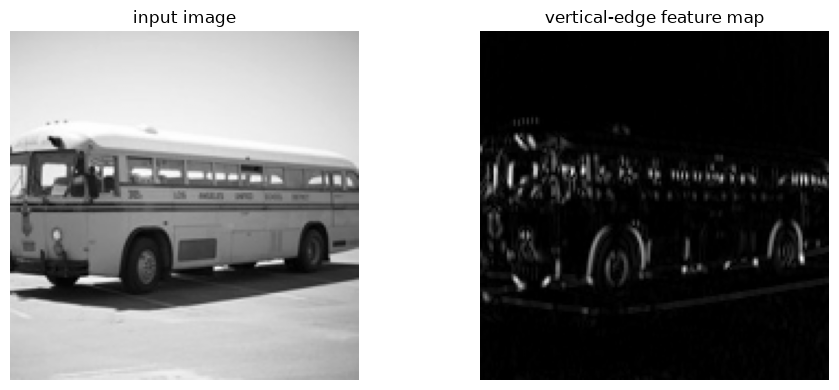

In [57]:
# Apply a hand-set vertical-edge filter to one photo. One Conv2d, one filter, no training.

from PIL import Image

# Pick the first image from the first class in the catalogue.
sample_path, _ = catalogue.samples[0]
img = Image.open(sample_path).convert("L").resize((160, 160))
tensor = torch.from_numpy(np.asarray(img, dtype=np.float32))[None, None]

# A Conv2d with a hand-set kernel — no learning, we just use the layer as a sliding window.
vertical_edge = torch.tensor([[1., 0., -1.],
                              [1., 0., -1.],
                              [1., 0., -1.]])[None, None]
conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
with torch.no_grad():
    conv.weight.copy_(vertical_edge)

feature_map = conv(tensor).squeeze().detach()
print(f"image path:         {sample_path}")
print(f"image shape:        {tuple(tensor.shape)}  (batch, channels, H, W)")
print(f"feature map shape:  {tuple(feature_map.shape)}  (160-3+1 = 158 on each side)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img, cmap="gray"); ax1.set_title("input image"); ax1.axis("off")
ax2.imshow(feature_map.abs(), cmap="gray"); ax2.set_title("vertical-edge feature map"); ax2.axis("off")
plt.tight_layout(); plt.show()

## Section 2 — Inside the CNN: pooling, batch norm, dropout  *(≈50 min)*

**The problem pooling solves.** A single Conv2d layer with 32 filters on a 160×160
image produces 32 feature maps of 158×158 = **798,912 numbers**. Stack three such
layers and you're at millions of numbers per image before you've reached the dense
head. Training that many numbers is slow, memory-hungry, and *mostly wasted* —
because the actual information in a feature map is sparse (edges and textures sit
in a small fraction of pixels; the rest is near-zero).

**Pooling** shrinks each feature map by sliding a small window and keeping one
number per window. Two flavours:

- **MaxPool** — keep the largest value. *"Was the pattern anywhere in this
  neighbourhood?"* The default in almost every CNN you'll see.
- **AvgPool** — keep the mean. *"How strong was the pattern on average here?"* Most
  commonly used **once**, at the very end of the backbone (global average pool), to
  turn a 2-D feature map into a vector for the classifier.

A 2×2 MaxPool with stride 2 **halves** the height and width — 158×158 becomes
79×79, and the parameter cost of the next layer drops by 4×.

<div dir="rtl" align="right">

## القسم الثاني — داخل الشبكة: التجميع وتطبيع الدفعات والإسقاط العشوائي *(نحو ٥٠ دقيقة)*

**المشكلة التي يحلّها التجميع.** طبقة `Conv2d` واحدة بـ٣٢ مرشِّحًا على صورة ١٦٠×١٦٠
تُنتج ٣٢ خريطة سمات ١٥٨×١٥٨ = **٧٩٨٬٩١٢ عددًا**. كدِّس ثلاث طبقات كهذه فتصل إلى
ملايين الأعداد للصورة قبل بلوغ الرأس الكثيف. وتدريب هذا العدد بطيء ومُستهلِك للذاكرة
و*مُهدَر في معظمه* — لأن المعلومات الفعلية في خريطة السمات متناثرة (الحواف والمَلامس
في جزء صغير من البكسلات، والباقي قريب من الصفر).

**التجميع** يُصغِّر كل خريطة سمات بتمرير نافذة صغيرة والإبقاء على عدد واحد لكل
نافذة. نوعان:

- **التجميع الأقصى** (`MaxPool`) — احتفظ بأكبر قيمة. *«هل ظهرت النقشة في أي مكان من
  هذا الجوار؟»* وهو الافتراضيّ في كل شبكة التفافية تقريبًا.
- **التجميع المتوسِّط** (`AvgPool`) — احتفظ بالمتوسِّط. *«كم كانت النقشة قويّة في
  المتوسِّط هنا؟»* ويُستعمل غالبًا **مرّة واحدة** في آخر العمود الفقري (تجميع متوسِّط
  شامل)، ليحوّل خريطة سمات ثنائية البعد إلى متّجه للمصنِّف.

`MaxPool` ٢×٢ بخطوة ٢ **ينصّف** الارتفاع والعرض — ١٥٨×١٥٨ تصير ٧٩×٧٩، وتنخفض كلفة
الطبقة التالية ٤ أضعاف.

</div>

### Task 2.1 — MaxPool and AvgPool, side by side

Apply **MaxPool2d(2)** and **AvgPool2d(2)** to the feature map from Section 1. Before
you run it, predict the output shape with the formula `(input − kernel) // stride + 1`
and record it in `PREDICTED_POOL_SHAPE`.

Then print both pooled feature maps' shapes and compare — the formula and the real
shape must match.

<div dir="rtl" align="right">

### المهمة ٢٫١ — `MaxPool` و`AvgPool` جنبًا إلى جنب

طبّق `MaxPool2d(2)` و`AvgPool2d(2)` على خريطة السمات من القسم الأول. قبل أن تشغّل،
تنبّأ بشكل الخرج بالمعادلة `(الدخل − النواة) // الخطوة + ١` واحتفظ بها في
`PREDICTED_POOL_SHAPE`.

ثم اطبع شكلَي خريطتَي السمات المجمَّعتين وقارن — يجب أن تتطابق المعادلة مع الشكل
الحقيقي.

</div>


In [58]:
# ────────────────────────────────────────────────────────────────────
# 1) Both pooling layers take kernel_size=2. Stride defaults to kernel_size.
# 2) The feature_map tensor is 2-D (H, W). nn.MaxPool2d expects (N, C, H, W).
#    Add two leading dimensions with `feature_map[None, None]` or `.unsqueeze(0).unsqueeze(0)`.
# 3) Formula: a 158x158 map with a 2x2 kernel and stride 2 -> (158-2)//2+1 = 79.
# 4) After pooling, drop the leading dims for plotting with `.squeeze()`.
# Search: "pytorch nn MaxPool2d AvgPool2d kernel_size stride"
# https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
#
# ١) تأخذ طبقتا التجميع `kernel_size=2`. والافتراضي للخطوة هو `kernel_size`.
# ٢) `feature_map` ثنائيّ البعد (H, W). و`nn.MaxPool2d` يتوقّع (N, C, H, W).
#    أضِف بعدين من اليسار بـ`feature_map[None, None]` أو `.unsqueeze(0).unsqueeze(0)`.
# ٣) المعادلة: خريطة ١٥٨×١٥٨ بنواة ٢×٢ وخطوة ٢ ← (158-2)//2+1 = 79.
# ٤) بعد التجميع أسقِط الأبعاد الأمامية للرسم بـ`.squeeze()`.
# ابحث عن: "pytorch nn MaxPool2d AvgPool2d kernel_size stride"
# https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
# ────────────────────────────────────────────────────────────────────

# TODO: Build the two pooling layers and apply them to feature_map (reshaped to 4-D).
# مهمة: ابنِ طبقتَي التجميع وطبّقهما على `feature_map` (مُعادة التشكيل إلى ٤ أبعاد).
H, W = feature_map.shape[-2:]
PREDICTED_POOL_SHAPE = (H - 2) // 2 + 1          # 79

max_pool = nn.MaxPool2d(kernel_size=2)
avg_pool = nn.AvgPool2d(kernel_size=2)

x = feature_map.reshape(1, -1, H, W)      # أيًّا كان شكله الأصلي → (1, C, H, W)

pooled_max = max_pool(x).squeeze()
pooled_avg = avg_pool(x).squeeze()


### Task 2.2 — Pooling inside a mini CNN

Build a small CNN with three `Conv → ReLU → Pool` blocks, then a flatten + a dense
head for 5 classes. **The whole point of this task is to watch the shapes.** Use
`torchinfo.summary` to print every intermediate size and confirm pooling is halving
H and W at each stage.

Architecture:
- Block 1: `Conv2d(3, 16, 3)` → `ReLU` → `MaxPool2d(2)`
- Block 2: `Conv2d(16, 32, 3)` → `ReLU` → `MaxPool2d(2)`
- Block 3: `Conv2d(32, 64, 3)` → `ReLU` → `MaxPool2d(2)`
- Flatten → `Linear(?, 128)` → `ReLU` → `Linear(128, 5)`

The `?` is the thing pooling made predictable. For a 160×160 input, after three
conv+pool blocks the spatial dims are `((160-2)//2 - 2)//2 - 2)//2 = 18`, and the
channel count is 64, so the flatten dim is `64 * 18 * 18 = 20,736`. You will *not*
hard-code that — you'll use `nn.AdaptiveAvgPool2d` to lock it to a known size,
regardless of input. This is the same trick ResNet uses, and D5 relies on it.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — التجميع داخل شبكة صغيرة

ابنِ شبكة التفافية صغيرة بثلاث كتل `التفاف → ReLU → تجميع`، ثم تسطيح + رأس كثيف
لـ٥ فئات. **مقصد المهمة كلّه مراقبة الأشكال.** استعمل `torchinfo.summary` لطبع كل
حجم وسيط وتأكّد أن التجميع يُنصِّف H وW في كل مرحلة.

المعمارية:
- كتلة ١: `Conv2d(3, 16, 3)` ← `ReLU` ← `MaxPool2d(2)`
- كتلة ٢: `Conv2d(16, 32, 3)` ← `ReLU` ← `MaxPool2d(2)`
- كتلة ٣: `Conv2d(32, 64, 3)` ← `ReLU` ← `MaxPool2d(2)`
- تسطيح ← `Linear(?, 128)` ← `ReLU` ← `Linear(128, 5)`

العلامة `?` هي ما جعلها طبقات التجميع قابلة للتنبّؤ. لصورة دخل ١٦٠×١٦٠، بعد ثلاث
كتل التفاف+تجميع يصبح البعد المكاني `((160-2)//2 - 2)//2 - 2)//2 = 18`، وعدد
القنوات ٦٤، فيكون بُعد التسطيح `64 * 18 * 18 = 20٬736`. ولن تُثبِّت هذا العدد
يدويًا — بل ستستعمل `nn.AdaptiveAvgPool2d` لتثبيته على حجم معلوم مهما كان الدخل.
وهي الحيلة نفسها التي تستعملها ResNet، ويعتمد عليها اليوم الخامس.

</div>


In [59]:
# ────────────────────────────────────────────────────────────────────
# 1) nn.Sequential(...) is the cleanest way to build this. Three Conv+ReLU+Pool
#    blocks in order, then nn.AdaptiveAvgPool2d((4, 4)), then nn.Flatten,
#    then the Linear layers.
# 2) AdaptiveAvgPool2d((4, 4)) forces the spatial dims to exactly 4x4 before
#    the flatten, so the Linear's input is 64*4*4 = 1024, regardless of input size.
# 3) torchinfo.summary(model, input_size=(1, 3, 160, 160)) prints each layer's
#    output shape and parameter count. Read it top-to-bottom.
# Search: "pytorch nn Sequential Conv2d MaxPool2d AdaptiveAvgPool2d"
# https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html
#
# ١) `nn.Sequential(...)` أنظف طريقة لبناء هذا. ثلاث كتل التفاف+ReLU+تجميع
#    بالترتيب، ثم `nn.AdaptiveAvgPool2d((4, 4))`، ثم `nn.Flatten`، ثم طبقتا
#    `Linear`.
# ٢) `AdaptiveAvgPool2d((4, 4))` يفرض الأبعاد المكانية على ٤×٤ قبل التسطيح،
#    فيصبح دخل `Linear` هو ٦٤×٤×٤ = ١٠٢٤ مهما كان حجم الدخل.
# ٣) `torchinfo.summary(model, input_size=(1, 3, 160, 160))` يطبع شكل خرج كل
#    طبقة وعدد معاملاتها. اقرأه من أعلى إلى أسفل.
# ابحث عن: "pytorch nn Sequential Conv2d MaxPool2d AdaptiveAvgPool2d"
# https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html
# ────────────────────────────────────────────────────────────────────

# TODO: Build the mini CNN as nn.Sequential with the three Conv-ReLU-Pool blocks.
# مهمة: ابنِ الشبكة الصغيرة بـ`nn.Sequential` بالكتل الثلاث التفاف-ReLU-تجميع.

def make_mini_cnn(num_classes: int = 5) -> nn.Module:
    """Three Conv-ReLU-Pool blocks, then a dense head."""
    return nn.Sequential(
        nn.Conv2d(3, 16, 3),  nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(),
        nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
        nn.Linear(128, num_classes),
    )


model = make_mini_cnn()
summary(model, input_size=(1, 3, 160, 160))


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 5]                    --
├─Conv2d: 1-1                            [1, 16, 158, 158]         448
├─ReLU: 1-2                              [1, 16, 158, 158]         --
├─MaxPool2d: 1-3                         [1, 16, 79, 79]           --
├─Conv2d: 1-4                            [1, 32, 77, 77]           4,640
├─ReLU: 1-5                              [1, 32, 77, 77]           --
├─MaxPool2d: 1-6                         [1, 32, 38, 38]           --
├─Conv2d: 1-7                            [1, 64, 36, 36]           18,496
├─ReLU: 1-8                              [1, 64, 36, 36]           --
├─MaxPool2d: 1-9                         [1, 64, 18, 18]           --
├─AdaptiveAvgPool2d: 1-10                [1, 64, 4, 4]             --
├─Flatten: 1-11                          [1, 1024]                 --
├─Linear: 1-12                           [1, 128]                  131,200
├─

### Task 2.3 — Batch normalisation: add it to the mini CNN

Pooling controls the **size** of the feature maps. Batch normalisation controls their **scale**.
As training changes the weights of one layer, the range of numbers it hands to the next layer
drifts, and every later layer has to keep re-adapting to a moving target. Batch norm fixes the
scale after every convolution. For each channel `c` of a conv output `x` with shape
`(batch, channels, height, width)`:

```
mean_c = average of x[:, c, :, :]                 over the batch, the rows and the columns
var_c  = average of (x[:, c, :, :] − mean_c)²     same positions; divided by N, not N − 1
x̂      = (x − mean_c) / sqrt(var_c + eps)         eps = 1e-5 avoids dividing by zero
out    = γ_c · x̂ + β_c                            γ starts at 1, β at 0; both are learned
```

Every channel leaves the layer with mean ≈ 0 and standard deviation ≈ 1, whatever the layers
before it did. Then `γ` and `β` let the network shift and stretch it back if that helps. That
stability is why networks with batch norm train faster and tolerate higher learning rates.

Three details:

- **It has `2 × channels` parameters.** `nn.BatchNorm2d(16)` has 32: sixteen `γ` (`.weight`)
  and sixteen `β` (`.bias`).
- **It also keeps two buffers that are not parameters.** `running_mean` and `running_var` are
  updated on every training batch (a moving average, `momentum=0.1`), and no gradient touches
  them. They exist for evaluation: when the model scores one photo, there is no batch to take a
  mean over, so the layer uses these stored averages instead. **Which statistics it uses is set
  by `model.train()` / `model.eval()`** — Section 4 comes back to this.
- **The convolution before it needs no bias.** Subtracting `mean_c` cancels any constant the
  convolution added, and `β` does that job anyway. So the convs are written `bias=False`.

Write `make_cnn`: Task 2.2's mini CNN with `nn.BatchNorm2d` after each of the three convolutions,
before the `ReLU`. **This is the model Section 4 trains.** Then this course's habit: compute the
formula above by hand on one real batch, and match the layer to `1e-5`.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — تطبيع الدفعات (Batch Normalization): أضِفه إلى الشبكة الصغيرة

التجميع يضبط **حجم** خرائط السمات، وتطبيع الدفعات يضبط **مقياسها**. فحين يُغيّر التدريب أوزان
طبقة، ينجرف مدى الأعداد التي تُسلّمها إلى الطبقة التالية، وتضطرّ كل طبقة لاحقة إلى التكيّف من
جديد مع هدف متحرّك. وتطبيع الدفعات يُثبّت المقياس بعد كل التفاف. فلكل قناة `c` من خرج التفاف `x`
شكله `(batch, channels, height, width)`:

```
mean_c = average of x[:, c, :, :]                 over the batch, the rows and the columns
var_c  = average of (x[:, c, :, :] − mean_c)²     same positions; divided by N, not N − 1
x̂      = (x − mean_c) / sqrt(var_c + eps)         eps = 1e-5 avoids dividing by zero
out    = γ_c · x̂ + β_c                            γ starts at 1, β at 0; both are learned
```

فتخرج كل قناة من الطبقة بمتوسّط ≈ ٠ وانحراف معياري ≈ ١، أيًّا كان ما فعلته الطبقات قبلها. ثم يسمح
`γ` و`β` للشبكة بأن تُزيحها وتمدّها من جديد إن كان ذلك أنفع. وهذا الثبات سبب أن الشبكات التي فيها
تطبيع دفعات تتدرّب أسرع وتحتمل معدّلات تعلّم أعلى.

ثلاث تفاصيل:

- **له `2 × channels` من المعاملات.** فلـ`nn.BatchNorm2d(16)` اثنان وثلاثون: ستة عشر `γ`
  (`.weight`) وستة عشر `β` (`.bias`).
- **ويحفظ أيضًا مخزنين ليسا معاملات.** `running_mean` و`running_var` يُحدَّثان مع كل دفعة تدريب
  (متوسّط متحرّك بـ`momentum=0.1`)، ولا يمسّهما تدرّج. ووُجدا للتقييم: فحين يُقيّم النموذج صورة
  واحدة لا توجد دفعة يُؤخذ متوسّطها، فتستخدم الطبقة هذين المتوسّطين المحفوظين بدلًا من ذلك. **وأيّ
  الإحصاءات تستخدم يُحدّده `model.train()` / `model.eval()`** — ويعود القسم الرابع إلى هذا.
- **الالتفاف الذي قبله لا يحتاج إلى انحياز.** فطرح `mean_c` يُلغي أي ثابت أضافه الالتفاف، و`β`
  يقوم بتلك المهمة على أي حال. ولذلك تُكتب الالتفافات بـ`bias=False`.

اكتب `make_cnn`: شبكة المهمة ٢٫٢ الصغيرة مع `nn.BatchNorm2d` بعد كلٍّ من الالتفافات الثلاثة، قبل
الـ`ReLU`. **وهذا هو النموذج الذي يُدرّبه القسم الرابع.** ثم عادة هذا المقرّر: احسب المعادلة أعلاه
بيدك على دفعة حقيقية واحدة، وطابِق الطبقة حتى `1e-5`.

</div>

In [60]:
# ────────────────────────────────────────────────────────────────────
# 1) In make_cnn, nn.BatchNorm2d(c) goes right after each conv, where c is that conv's
#    out_channels: 16, then 32, then 64.
# 2) By hand: the per-channel mean is conv_out.mean(dim=(0, 2, 3), keepdim=True) —
#    over the batch, the rows and the columns, keeping a (1, 16, 1, 1) shape.
# 3) The variance divides by N: .var(..., unbiased=False). Then (x - mean) /
#    torch.sqrt(var + bn.eps), times bn.weight plus bn.bias, both viewed as (1, -1, 1, 1).
# Search: "pytorch BatchNorm2d formula running_mean training mode unbiased variance"
# https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
#
# ١) في `make_cnn` يأتي `nn.BatchNorm2d(c)` بعد كل التفاف مباشرة، و`c` هي `out_channels`
#    لذلك الالتفاف: ١٦ ثم ٣٢ ثم ٦٤.
# ٢) باليد: متوسّط كل قناة هو `conv_out.mean(dim=(0, 2, 3), keepdim=True)` — على الدفعة
#    والصفوف والأعمدة، مع الإبقاء على شكل (1, 16, 1, 1).
# ٣) التباين يقسم على N: `.var(..., unbiased=False)`. ثم `(x - mean) / torch.sqrt(var + bn.eps)`،
#    مضروبًا في `bn.weight` ومضافًا إليه `bn.bias`، وكلاهما بشكل (1, -1, 1, 1).
# ابحث عن: "pytorch BatchNorm2d formula running_mean training mode unbiased variance"
# ────────────────────────────────────────────────────────────────────

def make_cnn(num_classes: int = 5) -> nn.Module:
    """Task 2.2's mini CNN, with batch norm after every convolution."""
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, bias=False),
        # TODO: Normalise the 16 channels the first convolution produced.
        # مهمة: طبِّع القنوات الست عشرة التي أنتجها الالتفاف الأول.
                nn.BatchNorm2d(16),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, bias=False),
        # TODO: Normalise the 32 channels the second convolution produced.
        # مهمة: طبِّع القنوات الاثنتين والثلاثين التي أنتجها الالتفاف الثاني.
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, bias=False),
        # TODO: Normalise the 64 channels the third convolution produced.
        # مهمة: طبِّع القنوات الأربع والستين التي أنتجها الالتفاف الثالث.
        nn.ReLU(), nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(),
        nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
        nn.Linear(128, num_classes),
    )
torch.manual_seed(42)
cnn = make_cnn()
to_tensor_160 = transforms.Compose([transforms.Resize((160, 160)), transforms.ToTensor()])
xb = torch.stack([to_tensor_160(Image.open(catalogue.samples[i][0]).convert("RGB"))
                  for i in TRAIN_IDX[:8]])
with torch.no_grad():
    conv_out = cnn[0](xb)                     # the first conv's output
    bn = cnn[1]
    bn.train()                                # batch statistics, as in training
    bn_by_layer = bn(conv_out)
    # TODO: Batch norm by hand: per-channel mean and variance over dims (0, 2, 3), dividing by N; then (x - mean) / sqrt(var + bn.eps); then times bn.weight plus bn.bias.
    # مهمة: تطبيع الدفعات بيدك: متوسّط كل قناة وتباينها على المحاور (0, 2, 3) بالقسمة على N؛ ثم `(x - mean) / sqrt(var + bn.eps)`؛ ثم الضرب في `bn.weight` وإضافة `bn.bias`.
       
def make_cnn(num_classes: int = 5) -> nn.Module:
    """Task 2.2's mini CNN, with batch norm after every convolution."""
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, bias=False),
        nn.BatchNorm2d(16),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d((4, 4)),
        nn.Flatten(),
        nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
        nn.Linear(128, num_classes),
    )


torch.manual_seed(42)
cnn = make_cnn()
to_tensor_160 = transforms.Compose([transforms.Resize((160, 160)), transforms.ToTensor()])
xb = torch.stack([to_tensor_160(Image.open(catalogue.samples[i][0]).convert("RGB"))
                  for i in TRAIN_IDX[:8]])

with torch.no_grad():
    conv_out = cnn[0](xb)                     # the first conv's output
    bn = cnn[1]
    bn.train()                                # batch statistics, as in training
    bn_by_layer = bn(conv_out)

    mean = conv_out.mean(dim=(0, 2, 3), keepdim=True)
    var  = conv_out.var(dim=(0, 2, 3), keepdim=True, unbiased=False)
    x_hat = (conv_out - mean) / torch.sqrt(var + bn.eps)
    bn_by_hand = x_hat * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

BN_GAP = (bn_by_hand - bn_by_layer).abs().max().item()
channel_means = bn_by_layer.mean(dim=(0, 2, 3))
channel_stds = bn_by_layer.std(dim=(0, 2, 3))

def n_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"first conv output: {tuple(conv_out.shape)} = (batch, channels, height, width)")
print(f"by hand vs nn.BatchNorm2d: largest disagreement {BN_GAP:.1e}")
print(f"after batch norm, channel means {channel_means.min():+.4f} to {channel_means.max():+.4f}, "
      f"stds {channel_stds.min():.4f} to {channel_stds.max():.4f}")
print(f"\nBatchNorm2d(16): {n_params(bn)} parameters (gamma and beta), "
      f"buffers {[name for name, _ in bn.named_buffers()]}")
print(f"mini CNN {n_params(make_mini_cnn()):,} parameters -> with batch norm "
      f"{n_params(cnn):,}: the convs lost 112 biases, the three BatchNorm2d layers added 224")

first conv output: (8, 16, 158, 158) = (batch, channels, height, width)
by hand vs nn.BatchNorm2d: largest disagreement 9.5e-07
after batch norm, channel means -0.0000 to +0.0000, stds 0.9966 to 1.0000

BatchNorm2d(16): 32 parameters (gamma and beta), buffers ['running_mean', 'running_var', 'num_batches_tracked']
mini CNN 155,429 parameters -> with batch norm 155,541: the convs lost 112 biases, the three BatchNorm2d layers added 224


### Task 2.4 — Dropout, in detail

Nothing to write in this task. Read it, run the cell, and change the number it suggests. Dropout is
one line of PyTorch, and most people use it without knowing the details below.

**What it does.** `nn.Dropout(p)` is a layer with no weights. In training, every time a batch passes
through it, it sets each value to zero with probability `p`, independently, with a fresh random
choice on every batch. With `p = 0.5`, about half of a layer's activations vanish on each step, and
which half changes from step to step.

**Why that helps.** No unit can rely on any particular other unit being there. So the network
cannot build a fragile combination of features that only works together on the training images —
exactly the kind of combination that memorises 320 photographs. Each step trains a different,
randomly thinned sub-network, and at the end you use all of them at once, which behaves like an
average of many networks. Dropout is a **regulariser**: it gives up some training accuracy to
shrink the gap between training and validation. It does not make training faster; a network with
dropout usually needs more epochs.

**The scaling — the detail people get wrong.** Suppose half the values were zeroed in training and
none at evaluation. Then the next layer would receive inputs about twice as large at evaluation as
it was trained on. PyTorch corrects for this during training: the values it keeps are multiplied
by `1 / (1 − p)` — by 2 when `p = 0.5` — so the **expected** value of every activation is the same
in both modes. At evaluation, dropout does nothing at all: no zeros and no scaling. (This is
*inverted* dropout. The original paper scaled at test time instead; the expected value is the same,
the correction just lives in the other mode.)

**Where it goes.** In the classifier head: after a hidden `nn.ReLU`, before the next `nn.Linear` —
in `make_cnn`, between `nn.ReLU()` and `nn.Linear(128, num_classes)`. The usual range for `p` is 0.2
to 0.5. Small CNNs rarely put dropout between convolution layers; batch norm does the stabilising
there.

**It depends on a switch.** Dropout reads `self.training`, a flag that every `nn.Module` has.
`model.train()` sets it to `True` and `model.eval()` sets it to `False`. Section 4 is where that
switch gets written into the training loop.

The cell pushes a row of twenty ones through `nn.Dropout(0.5)`: twice in training mode, then once
in evaluation mode.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — الإسقاط العشوائي (Dropout) بالتفصيل

لا شيء تكتبه في هذه المهمة. اقرأها، وشغّل الخلية، وغيّر العدد الذي تقترحه. فالإسقاط العشوائي سطر
واحد في PyTorch، ويستخدمه أكثر الناس دون أن يعرفوا التفاصيل التالية.

**ما يفعله.** `nn.Dropout(p)` طبقة بلا أوزان. في التدريب، كلما مرّت بها دفعة، تجعل كل قيمة صفرًا
باحتمال `p`، كلَّ قيمة مستقلّةً عن غيرها، باختيار عشوائي جديد في كل دفعة. فعند `p = 0.5` يختفي نحو
نصف تنشيطات الطبقة في كل خطوة، ويتغيّر النصف المُختفي من خطوة إلى أخرى.

**لماذا يفيد ذلك.** لا تستطيع أي وحدة أن تعتمد على وجود وحدة أخرى بعينها. فلا تستطيع الشبكة أن تبني
توليفة هشّة من الخصائص لا تعمل إلا مجتمعةً على صور التدريب — وهي بالضبط التوليفة التي تحفظ ٣٢٠
صورة عن ظهر قلب. فكل خطوة تُدرّب شبكة فرعية مختلفة مُخفَّفة عشوائيًا، وفي النهاية تستخدمها كلها معًا،
فيتصرّف ذلك كمتوسّط لشبكات كثيرة. والإسقاط العشوائي **مُنظِّم** (regulariser): يتنازل عن شيء من
دقّة التدريب ليُضيّق الفجوة بين التدريب والتحقّق. ولا يُسرّع التدريب؛ فالشبكة التي فيها إسقاط عشوائي
تحتاج عادةً إلى حقب أكثر.

**التحجيم — التفصيل الذي يُخطئ فيه الناس.** لو صُفِّر نصف القيم في التدريب ولا شيء منها عند التقييم،
لتلقّت الطبقة التالية عند التقييم مُدخلات أكبر بنحو الضعف ممّا تدرّبت عليه. فتُصحّح PyTorch ذلك أثناء
التدريب: القيم التي تُبقيها تُضرب في `1 / (1 − p)` — أي في ٢ عند `p = 0.5` — فتبقى القيمة
**المتوقَّعة** لكل تنشيط واحدةً في الوضعين. أمّا عند التقييم فلا يفعل الإسقاط العشوائي شيئًا البتّة: لا
أصفار ولا تحجيم. (ويُسمّى هذا الإسقاط العشوائي *المعكوس*. والورقة الأصلية كانت تُحجّم وقت الاختبار؛
والقيمة المتوقَّعة واحدة، وإنما يقع التصحيح في الوضع الآخر.)

**أين يوضع.** في رأس التصنيف: بعد `nn.ReLU` مخفيّة وقبل `nn.Linear` التالية — وفي `make_cnn` بين
`nn.ReLU()` و`nn.Linear(128, num_classes)`. والمدى المعتاد لـ`p` من ٠٫٢ إلى ٠٫٥. ونادرًا ما تضع الشبكات
الالتفافية الصغيرة الإسقاط العشوائي بين طبقات الالتفاف؛ فتطبيع الدفعات يتولّى التثبيت هناك.

**يعتمد على مفتاح.** يقرأ الإسقاط العشوائي `self.training`، وهي راية يملكها كل `nn.Module`.
فـ`model.train()` يجعلها `True`، و`model.eval()` يجعلها `False`. والقسم الرابع هو حيث يُكتب هذا
المفتاح في حلقة التدريب.

تُمرّر الخلية صفًّا من عشرين واحدًا عبر `nn.Dropout(0.5)`: مرّتين في وضع التدريب، ثم مرّة في وضع
التقييم.

</div>

In [61]:
torch.manual_seed(42)
drop = nn.Dropout(p=0.5)
ones = torch.ones(1, 20)

drop.train()       # training mode: zero each value with probability p, scale the rest by 1/(1-p)
print("train, pass 1:", [round(v, 2) for v in drop(ones)[0].tolist()])
print("train, pass 2:", [round(v, 2) for v in drop(ones)[0].tolist()])
drop.eval()        # evaluation mode: the identity
print("eval:         ", [round(v, 2) for v in drop(ones)[0].tolist()])

drop.train()
many = drop(torch.ones(100_000))
print(f"\n100,000 ones in training mode: {(many == 0).float().mean():.3f} zeroed, "
      f"the rest = {[round(v, 4) for v in many[many > 0].unique().tolist()]}, "
      f"mean = {many.mean():.3f}")
print(f"nn.Dropout has {sum(p.numel() for p in drop.parameters())} parameters")

train, pass 1: [2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 0.0, 0.0, 2.0, 2.0, 2.0, 2.0, 0.0, 0.0, 2.0, 0.0, 2.0, 0.0, 0.0, 2.0]
train, pass 2: [2.0, 0.0, 2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0]
eval:          [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

100,000 ones in training mode: 0.500 zeroed, the rest = [2.0], mean = 1.000
nn.Dropout has 0 parameters


**Change one thing:** set `p=0.2` and rerun. Now about a fifth of the values are zeroed, and the
ones that survive are `1.25`, which is `1 / (1 − 0.2)`. The mean of the 100,000 stays close to 1 for
every `p`. Keeping it there is the whole job of the scaling.

**At home, once Section 4 has run:** add `nn.Dropout(0.5)` to `make_cnn`'s head and rerun Section 4.
On the machine this notebook was written on, the baseline's validation accuracy rose from 0.54
to 0.64 and the augmentation gap shrank from +0.09 to +0.01. Dropout and
augmentation fight the same overfitting, so each leaves less for the other to fix. With 80
validation images, one image is 1.25 points — treat differences under about 0.05 as noise.

<div dir="rtl" align="right">

**غيّر شيئًا واحدًا:** اجعل `p=0.2` وأعد التشغيل. الآن يُصفَّر نحو خُمس القيم، والباقية تساوي `1.25`،
أي `1 / (1 − 0.2)`. ويبقى متوسّط المئة ألف قريبًا من ١ مهما كانت `p`. وإبقاؤه هناك هو كل عمل التحجيم.

**في المنزل، بعد تشغيل القسم الرابع:** أضِف `nn.Dropout(0.5)` إلى رأس `make_cnn` وأعد تشغيل القسم
الرابع. وعلى الجهاز الذي كُتب عليه هذا الدفتر ارتفعت دقّة تحقّق تشغيلة الأساس من ٠٫٥٤ إلى
٠٫٦٤ وضاقت فجوة التكثير من +٠٫٠٩ إلى +٠٫٠١. فالإسقاط العشوائي والتكثير يحاربان
فرط المطابقة نفسه، فيترك كلٌّ منهما للآخر أقلّ ممّا يُصلحه. ومع ٨٠ صورة تحقّق تساوي الصورة الواحدة
١٫٢٥ نقطة — فعامِل الفروق الأصغر من نحو ٠٫٠٥ معاملة الضجيج.

</div>

## Section 3 — Augmentation  *(≈25 min)*

**The problem augmentation solves.** You have 400 images. A model trained on them
learns the shortcuts in *those exact 400 images* — the lighting, the angles, the
backgrounds — not the thing itself. Give it a car photographed from a different side
of the street and it hesitates.

**Augmentation** fixes this at zero data cost: before each training batch, flip,
rotate or crop each image at random. The network sees the same car from many angles
across epochs and learns the *invariant* part — "car-ness" — rather than
"car-pointing-right-under-sunlight."

The usual transforms:
- `RandomHorizontalFlip(p=0.5)` — mirrors half the batch left-right.
- `RandomRotation(15)` — tilts up to ±15°.
- `RandomResizedCrop(size, scale=(0.8, 1.0))` — crops a random fraction, resizes back.
- `ColorJitter(brightness=0.2, contrast=0.2)` — nudges exposure and contrast.

**Not all transforms are safe.** A vertical flip ruins a dataset of handwritten
digits ("6" becomes "9"). A 180° rotation ruins photos of cars (unless you expect
upside-down cars at test time). Task 3.2 is the validity check — this is where every
real project earns or loses its augmentation gain.

<div dir="rtl" align="right">

## القسم الثالث — التكثير *(نحو ٢٥ دقيقة)*

**المشكلة التي يحلّها التكثير.** لديك ٤٠٠ صورة. وأي نموذج يُدرَّب عليها يتعلّم
اختصارات *تلك الصور الأربعمئة بعينها* — إضاءتها، وزواياها، وخلفياتها — لا الشيء
نفسه. أرِه سيارة مُصوَّرة من الجهة الأخرى فيتردّد.

**التكثير** يُصلح هذا بلا كلفة بيانات: قبل كل دفعة تدريب، اقلب صورةً أو دوِّرها أو
اقتطع منها عشوائيًا. ترى الشبكة السيّارة ذاتها من زوايا كثيرة عبر الحقب فتتعلّم
الجزء **الثابت** — «السيّارية» — لا «السيّارة المتّجهة يمينًا تحت شمس الظهيرة».

التحويلات المعتادة:
- `RandomHorizontalFlip(p=0.5)` — يعكس نصف الدفعة أفقيًا.
- `RandomRotation(15)` — يُميل حتى ±١٥°.
- `RandomResizedCrop(size, scale=(0.8, 1.0))` — يقتطع جزءًا عشوائيًا ويُعيد التحجيم.
- `ColorJitter(brightness=0.2, contrast=0.2)` — يُحرّك الإضاءة والتباين قليلًا.

**ليست كل التحويلات آمنة.** القلب الرأسيّ يُفسد مجموعة أرقام مكتوبة بخطّ اليد
(«٦» يصير «٩»). والدوران ١٨٠° يُفسد صور السيّارات (إلا أن تنتظر سيّارات مقلوبة
وقت الاختبار). والمهمة ٣٫٢ هي فحص الصلاحية — وهنا يربح أو يخسر كل مشروع حقيقي
مكسبَ التكثير.

</div>


### Task 3.1 — See the transforms applied to real images

Pick one image. Apply each of the four common transforms to it independently and
display the originals + 4 variants as a 1×5 grid. Then do it on a different image —
sometimes a transform looks tame on one photo and savage on another.

<div dir="rtl" align="right">

### المهمة ٣٫١ — شاهد التحويلات مطبَّقةً على صور حقيقية

اختر صورة واحدة. طبّق كلًّا من التحويلات الأربعة عليها مستقلًّا واعرض الأصل مع
التنويعات الأربعة في شبكة ١×٥. ثم أعِد الكرَّة على صورة أخرى — فأحيانًا يبدو تحويل
وديعًا على صورة وقاسيًا على أخرى.

</div>


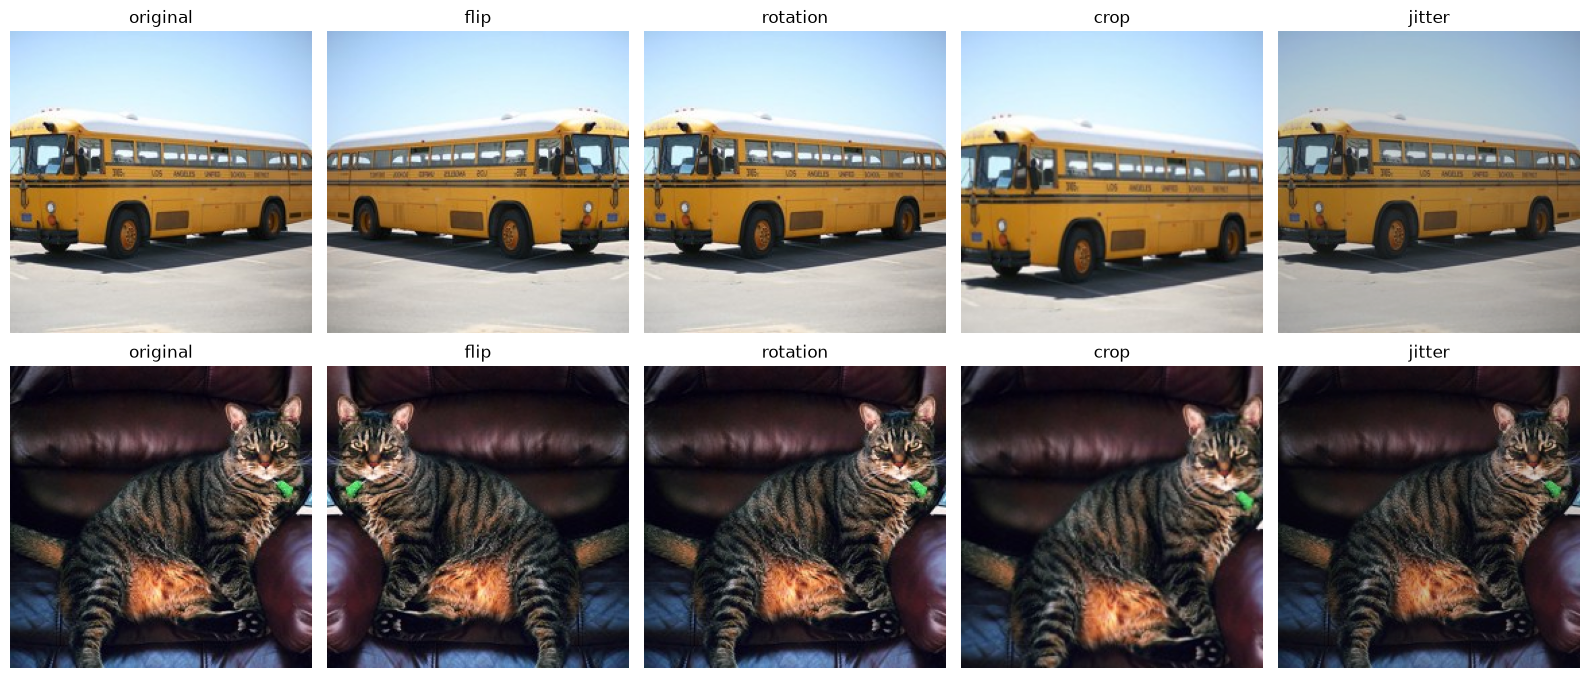

In [62]:
# ────────────────────────────────────────────────────────────────────
# 1) Each transform takes a PIL image and returns a PIL image, so you can call
#    them directly without wrapping in Compose.
# 2) The transforms are random — set torch.manual_seed(0) before each call if
#    you want reproducible outputs for the figure.
# 3) RandomResizedCrop needs a size argument; use the image's current size.
# 4) Make the figure plt.subplots(2, 5, figsize=(16, 7)) for two rows of five.
# Search: "torchvision transforms RandomHorizontalFlip RandomRotation RandomResizedCrop ColorJitter"
# https://pytorch.org/vision/stable/transforms.html
#
# ١) كل تحويل يأخذ صورة PIL ويُرجع صورة PIL، فتستطيع نداءه
#    مباشرة بلا `Compose`.
# ٢) التحويلات عشوائية — ثبّت البذرة بـ`torch.manual_seed(0)` قبل كل نداء إن
#    أردت نواتج قابلة للتكرار للشكل.
# ٣) `RandomResizedCrop` يحتاج وسيط `size`؛ استعمل حجم الصورة الحاليّ.
# ٤) اجعل الشكل `plt.subplots(2, 5, figsize=(16, 7))` لصفّين من خمسة.
# ابحث عن: "torchvision transforms RandomHorizontalFlip RandomRotation RandomResizedCrop ColorJitter"
# https://pytorch.org/vision/stable/transforms.html
# ────────────────────────────────────────────────────────────────────

sample_images = [catalogue.samples[0][0], catalogue.samples[80][0]]
# TODO: Build four transforms: horizontal flip, rotation, resized crop, colour jitter.
# مهمة: ابنِ أربعة تحويلات: قلب أفقيّ، تدوير، اقتطاع وتحجيم، خضخضة ألوان.

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for row, path in enumerate(sample_images):
    image = Image.open(path).convert("RGB")

    augmentations = [
        ("original",  None),
        ("flip",      transforms.RandomHorizontalFlip(p=1.0)),
        ("rotation",  transforms.RandomRotation(15)),
        ("crop",      transforms.RandomResizedCrop(image.size[::-1], scale=(0.8, 1.0))),
        ("jitter",    transforms.ColorJitter(brightness=0.2, contrast=0.2)),
    ]

    for col, (name, tf) in enumerate(augmentations):
        torch.manual_seed(0)
        axes[row, col].imshow(image if tf is None else tf(image))
        axes[row, col].set_title(name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### Task 3.2 — Validity: which transforms are safe for *this* data?

For each of the five transforms below, fill in `SAFE` with `True` or `False`, and
write one short sentence saying why. The TA reads these.

- `horizontal_flip` — a car is still a car when flipped left-right.
- `vertical_flip` — ask yourself: does flipping a cat upside-down still look like a
  cat the model should recognise?
- `rotation_15deg` — a cat tilted 15° is still a cat.
- `rotation_180deg` — a cat upside-down is almost certainly not what you'll see at
  deployment.
- `grayscale` — removes colour. Depends on whether colour is a signal for your
  classes.

An invalid transform doesn't just not help — it **actively hurts**, because you're
teaching the model that a wrong-looking image shares a label with a right-looking one.

<div dir="rtl" align="right">

### المهمة ٣٫٢ — الصلاحية: أي التحويلات آمنة لـ**هذه** البيانات؟

لكل تحويل من التحويلات الخمسة أدناه، املأ `SAFE` بـ`True` أو `False` واكتب جملة
قصيرة تقول لماذا. والمساعد يقرأ ما تكتب.

- `horizontal_flip` — السيّارة تبقى سيّارة إذا قُلبت أفقيًا.
- `vertical_flip` — اسأل نفسك: هل قلبُ قطّة رأسًا على عقب يُشبه قطّةً ينبغي للنموذج
  التعرّف عليها؟
- `rotation_15deg` — القطّة المائلة ١٥° قطّة.
- `rotation_180deg` — القطّة المقلوبة شبه مستحيل أن تراها وقت النشر.
- `grayscale` — يُزيل اللون. يعتمد على كون اللون إشارة لفئاتك.

التحويل غير الصالح لا يكتفي بألا ينفع — بل **يضرّ فعليًّا**، لأنك تُعلِّم النموذج
أن صورة بشكل خاطئ تتشارك عنوانًا مع صورة بشكل صحيح.

</div>


In [63]:
# ────────────────────────────────────────────────────────────────────
# 1) For each transform decide True/False and write one short reason.
# 2) The reasoning must mention THIS dataset (small_image_5class, everyday
#    objects), not augmentation in general.
# 3) At least four reasons are needed below for the sanity check to pass.
#
# ١) لكل تحويل قرِّر True/False واكتب سببًا قصيرًا.
# ٢) يجب أن يُشير السبب إلى **هذه** المجموعة (`small_image_5class`، كائنات
#    يوميّة) لا إلى التكثير بوجه عامّ.
# ٣) يحتاج فحص السلامة أربعة أسباب على الأقل أدناه.
# ────────────────────────────────────────────────────────────────────

    # TODO: safe=True/False, with a one-sentence reason tied to THIS dataset.
    # مهمة: safe=True/False، مع جملة سبب واحدة مرتبطة بهذه المجموعة بالذات.

VALIDITY = {
    "horizontal_flip": (
        True,
        "Everyday objects in this dataset have no inherent left-right meaning, so a mirrored "
        "car or cat is still the same class, and the photos already show both orientations."),

    "vertical_flip": (
        False,
        "Nothing in this dataset is photographed upside-down, so teaching the model that an "
        "inverted image shares the label trains it on a distribution it will never meet."),

    "rotation_15deg": (
        True,
        "A small tilt happens naturally in handheld photography, and these images already "
        "contain slight tilts, so the model should be invariant to it."),

    "rotation_180deg": (
        False,
        "Same reason as the vertical flip: these everyday objects are never captured upside-down, "
        "so the transform generates images far outside the real distribution and wastes capacity."),

    "grayscale": (
        False,
        "Colour is a distinguishing signal between these classes and the test images are in "
        "colour, so dropping it removes useful information without matching any real condition."),
}
for name, (safe, reason) in VALIDITY.items():
    print(f"{name:<18} {'SAFE' if safe else 'NOT SAFE'}")
    print(f"   {reason}\n")

horizontal_flip    SAFE
   Everyday objects in this dataset have no inherent left-right meaning, so a mirrored car or cat is still the same class, and the photos already show both orientations.

vertical_flip      NOT SAFE
   Nothing in this dataset is photographed upside-down, so teaching the model that an inverted image shares the label trains it on a distribution it will never meet.

rotation_15deg     SAFE
   A small tilt happens naturally in handheld photography, and these images already contain slight tilts, so the model should be invariant to it.

rotation_180deg    NOT SAFE
   Same reason as the vertical flip: these everyday objects are never captured upside-down, so the transform generates images far outside the real distribution and wastes capacity.

grayscale          NOT SAFE
   Colour is a distinguishing signal between these classes and the test images are in colour, so dropping it removes useful information without matching any real condition.



## Section 4 — The A/B experiment  *(≈45 min)*

The core deliverable. Same architecture, same seed, same epochs, same optimiser —
only the training transform changes. The CNN is Task 2.3's `make_cnn`, with batch norm. Everything else being equal, the **val accuracy
gap** between the two runs is augmentation's contribution. Record it.

**Setup:** the dataset is already structured as `train/<class>/*.jpg` and
`val/<class>/*.jpg`, so we point `ImageFolder` at each. Images come in at 160×160.
Training runs for 10 epochs with Adam at lr=1e-3 — enough time for both runs to
settle, short enough to finish inside the slot. Expect each run to take about 1–2
minutes on CPU.

<div dir="rtl" align="right">

## القسم الرابع — تجربة A/B *(نحو ٤٥ دقيقة)*

التسليم الأساسيّ. المعمارية نفسها، والبذرة نفسها، والحقب نفسها، والمُحسِّن نفسه —
التحويل في التدريب وحده يختلف. والشبكة هي `make_cnn` من المهمة ٢٫٣، بتطبيع الدفعات. فمع تساوي كل شيء، تكون **فجوة دقّة التحقّق** بين
التشغيلتين هي مساهمة التكثير. سجّلها.

**الإعداد:** البيانات مُنظَّمة أصلًا هكذا `train/<class>/*.jpg` و`val/<class>/*.jpg`،
فنُشير بـ`ImageFolder` إلى كلٍّ منهما. حجم الصور ١٦٠×١٦٠. والتدريب يستغرق ١٠ حقب
بـAdam عند `lr=1e-3` — زمن يكفي لاستقرار التشغيلتين ويبقى داخل الفترة. تستغرق كل
تشغيلة نحو دقيقة إلى دقيقتين على CPU.

</div>

### Task 4.1 — The validation transform (shared by both runs)

Validation data **must not** be augmented — otherwise your val accuracy depends on
random crops instead of the model. The val transform is just resize + ToTensor +
normalise, nothing random.

This is the most common silent bug in augmentation pipelines, so we put it first.

What each step does to one photograph:

| step | in | out |
|---|---|---|
| `transforms.Resize((160, 160))` | PIL image, any size | PIL image, 160×160 — every image the same size, so a batch can be stacked |
| `transforms.ToTensor()` | PIL image `(H, W, 3)`, uint8 0–255 | tensor `(3, H, W)`, float32 **divided by 255**: channels first, values in [0, 1] |
| `transforms.Normalize(mean, std)` | tensor in [0, 1] | `(x − mean) / std` **per channel** — three means and three stds for RGB |

`transforms.Compose([...])` runs them in order, and the order is not free: `Resize` and every
random augmentation work on the PIL image, `Normalize` works on a tensor, so `ToTensor` sits
between them. The mean and std are the ImageNet training images' statistics. They are not facts
about these 400 photos; they are what every pretrained `torchvision` model expects, so using
them now means nothing changes on D5.

<div dir="rtl" align="right">

### المهمة ٤٫١ — تحويل التحقّق (مشترك بين التشغيلتين)

**يجب ألّا** تُكثَّر بيانات التحقّق — وإلا صارت دقّة التحقّق تابعةً للاقتطاعات
العشوائية لا للنموذج. وتحويل التحقّق هو تحجيم + `ToTensor` + تطبيع، بلا شيء عشوائيّ.

وهو أشيع خطأ صامت في خطوط التكثير، فنضعه أوّلًا.

ما تفعله كل خطوة بالصورة الواحدة:

| الخطوة | الدخل | الخرج |
|---|---|---|
| `transforms.Resize((160, 160))` | صورة PIL بأي حجم | صورة PIL بحجم ١٦٠×١٦٠ — كل الصور بحجم واحد لتُكدَّس في دفعة |
| `transforms.ToTensor()` | صورة PIL `(H, W, 3)` من نوع uint8 بين ٠ و٢٥٥ | موتِّر `(3, H, W)` من نوع float32 **مقسومًا على ٢٥٥**: القنوات أولًا والقيم بين ٠ و١ |
| `transforms.Normalize(mean, std)` | موتِّر بين ٠ و١ | `(x − mean) / std` **لكل قناة** — ثلاثة متوسّطات وثلاثة انحرافات للألوان الثلاثة |

ويُشغّلها `transforms.Compose([...])` بالترتيب، والترتيب ليس حرًّا: فـ`Resize` وكل تكثير عشوائي
يعملان على صورة PIL، و`Normalize` يعمل على موتِّر، ولذلك يقع `ToTensor` بينهما. والمتوسّط
والانحراف هما إحصاءات صور تدريب ImageNet، وليسا حقيقة عن هذه الصور الأربعمئة؛ بل هما ما تنتظره كل
شبكة `torchvision` مُدرَّبة مسبقًا، فاستعمالهما الآن يعني ألّا يتغيّر شيء في اليوم الخامس.

</div>

In [64]:
# ────────────────────────────────────────────────────────────────────
# 1) transforms.Compose([...]) chains the steps.
# 2) Resize to (160, 160), then ToTensor, then Normalize with ImageNet statistics
#    (mean [0.485, 0.456, 0.406], std [0.229, 0.224, 0.225]). You'll meet the
#    same statistics on D5 — ResNet-18 expects them.
# 3) No RandomXxx in val_transform. If you add one by accident, your val numbers
#    stop meaning anything.
#
# ١) `transforms.Compose([...])` يُسلسل الخطوات.
# ٢) تحجيم إلى (١٦٠، ١٦٠)، ثم `ToTensor`، ثم `Normalize` بإحصاءات ImageNet
#    (المتوسِّط [0.485, 0.456, 0.406] والانحراف [0.229, 0.224, 0.225]). ستلتقي
#    بالإحصاءات نفسها يوم الخميس — فـResNet-18 تنتظرها.
# ٣) لا `RandomXxx` في `val_transform`. فإن أضفتَه سهوًا فقدت أرقام التحقّق
#    معناها.
# ────────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# TODO: Build val_transform: Resize -> ToTensor -> Normalize. No random anything.
# مهمة: ابنِ `val_transform`: تحجيم ← `ToTensor` ← `Normalize`. بلا شيء عشوائيّ.

val_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Task 4.2 — Two training transforms (baseline vs augmented)

The baseline uses the identical pipeline as validation: resize + tensor + normalise.
No augmentation.

The augmented version adds the four transforms from Section 3.1 **before** ToTensor,
and uses only the ones you marked valid in Task 3.2 (horizontal flip, small rotation,
resized crop; add a mild `ColorJitter` too).

<div dir="rtl" align="right">

### المهمة ٤٫٢ — تحويلان للتدريب (الأساس مقابل المكثَّر)

يستعمل الأساس خطّ التحقّق ذاته: تحجيم + موتِّر + تطبيع. بلا تكثير.

وتُضيف النسخة المكثَّرة التحويلات الأربعة من المهمة ٣٫١ **قبل** `ToTensor`، مستعملةً
فقط ما وسمتَه بالصلاحية في المهمة ٣٫٢ (قلب أفقيّ، تدوير بسيط، اقتطاع، مع خضخضة
ألوان خفيفة).

</div>


In [65]:
# ────────────────────────────────────────────────────────────────────
# 1) baseline_transform is val_transform's steps, nothing added.
# 2) aug_transform: Resize, then the four random transforms, then ToTensor, then
#    Normalize. Random operations work on PIL images, not tensors — do them before
#    ToTensor.
# 3) Keep RandomResizedCrop's scale conservative — (0.8, 1.0) is a reasonable start.
# 4) ColorJitter(brightness=0.2, contrast=0.2) is enough; stronger values will
#    hurt as much as they help.
#
# ١) `baseline_transform` خطواته هي خطوات `val_transform` نفسها، بلا إضافة.
# ٢) `aug_transform`: تحجيم، ثم التحويلات الأربعة العشوائية، ثم `ToTensor`،
#    ثم `Normalize`. العمليات العشوائية تعمل على صور PIL لا موتِّرات — فضعها
#    قبل `ToTensor`.
# ٣) أبقِ `scale` في `RandomResizedCrop` معتدلًا — (0.8, 1.0) بداية معقولة.
# ٤) `ColorJitter(brightness=0.2, contrast=0.2)` كافٍ؛ والقيم الأقوى تضرّ قدر
#    ما تنفع.
# ────────────────────────────────────────────────────────────────────

# TODO: Build baseline_transform (same as val_transform) and aug_transform (with four random transforms before ToTensor).
# مهمة: ابنِ `baseline_transform` (كـ`val_transform`) و`aug_transform` (بأربعة تحويلات عشوائية قبل `ToTensor`).
baseline_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

aug_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(160, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])



### Before the loop — `model.train()` and `model.eval()`

Batch norm (Task 2.3) and dropout (Task 2.4) are the two layers in this course that behave
differently in training and at evaluation. Both read the same flag, `self.training`, and a single
call sets it on the model and on every layer inside it:

| | after `model.train()` | after `model.eval()` |
|---|---|---|
| `nn.BatchNorm2d` | normalises with **this batch's** mean and variance, and **updates** `running_mean` / `running_var` | normalises with the stored `running_mean` / `running_var`, and updates nothing |
| `nn.Dropout` | zeros a random fraction `p` and scales the rest by `1 / (1 − p)` | does nothing |
| `nn.Conv2d`, `nn.Linear`, `nn.ReLU`, `nn.MaxPool2d` | no difference | no difference |

Three things the switch is **not**:

- **It does not turn gradients off.** That is `torch.no_grad()`, a separate switch that saves
  memory and time. The validation pass uses both: `model.eval()` for how the layers behave,
  `torch.no_grad()` for the bookkeeping.
- **It does not train anything.** `model.train()` only sets a flag. The optimiser step trains.
- **It does not stay where you left it.** A new model starts in training mode. Once the validation
  pass calls `model.eval()`, the model **stays** in evaluation mode until something calls
  `model.train()` again — so the loop calls `model.train()` at the top of **every** epoch, not once
  before it.

The two classic bugs, and both are silent:

- **`model.eval()` is missing.** Validation runs on batch statistics (and with dropout on, if the
  model has it). Each photo's prediction then depends on which other photos share its batch, and
  every validation batch **updates the running statistics** — measuring the model changes it.
- **`model.train()` is missing after the first validation pass.** Every later epoch trains with
  batch norm frozen on stale statistics and dropout off. Nothing crashes; the model just trains
  differently from the one you think you built.

The cell below shows the first bug on an untrained `make_cnn`: the same photo, scored inside two
different batches, in each mode. Then write both calls into `run_training` in Task 4.3.

<div dir="rtl" align="right">

### قبل الحلقة — `model.train()` و`model.eval()`

تطبيع الدفعات (المهمة ٢٫٣) والإسقاط العشوائي (المهمة ٢٫٤) هما الطبقتان الوحيدتان في هذا المقرّر
اللتان تتصرّفان في التدريب بخلاف تصرّفهما عند التقييم. وكلتاهما تقرأ الراية نفسها، `self.training`،
ونداء واحد يضبطها على النموذج وعلى كل طبقة داخله:

| | بعد `model.train()` | بعد `model.eval()` |
|---|---|---|
| `nn.BatchNorm2d` | يُطبّع بمتوسّط **هذه الدفعة** وتباينها، و**يُحدّث** `running_mean` / `running_var` | يُطبّع بـ`running_mean` / `running_var` المحفوظين، ولا يُحدّث شيئًا |
| `nn.Dropout` | يُصفّر نسبة عشوائية `p` ويُحجّم الباقي بـ`1 / (1 − p)` | لا يفعل شيئًا |
| `nn.Conv2d` و`nn.Linear` و`nn.ReLU` و`nn.MaxPool2d` | لا فرق | لا فرق |

ثلاثة أشياء **ليست** من عمل هذا المفتاح:

- **لا يوقف التدرّجات.** ذلك عمل `torch.no_grad()`، وهو مفتاح منفصل يوفّر الذاكرة والوقت. وتمريرة
  التحقّق تستخدم الاثنين: `model.eval()` لسلوك الطبقات، و`torch.no_grad()` لحفظ الحسابات.
- **لا يُدرّب شيئًا.** `model.train()` يضبط راية فقط، وخطوة المُحسِّن هي التي تُدرّب.
- **لا يبقى حيث تركته.** النموذج الجديد يبدأ في وضع التدريب. وما إن تنادي تمريرة التحقّق
  `model.eval()` حتى **يبقى** النموذج في وضع التقييم إلى أن ينادي شيءٌ `model.train()` من جديد —
  ولذلك تنادي الحلقة `model.train()` في بداية **كل** حقبة، لا مرّة واحدة قبلها.

والخطآن الشهيران، وكلاهما صامت:

- **غياب `model.eval()`.** يجري التحقّق بإحصاءات الدفعة (والإسقاط العشوائي يعمل إن كان في النموذج).
  فيصير تنبّؤ كل صورة تابعًا للصور التي تشاركها دفعتها، وتُحدّث كل دفعة تحقّق **الإحصاءات المتحرّكة**
  — فيصير قياس النموذج تغييرًا له.
- **غياب `model.train()` بعد أول تمريرة تحقّق.** فكل حقبة لاحقة تتدرّب وتطبيع الدفعات مُجمَّد على
  إحصاءات قديمة والإسقاط العشوائي مُطفأ. لا شيء ينهار، لكن النموذج يتدرّب بخلاف النموذج الذي تظنّ أنك
  بنيته.

تُري الخلية التالية الخطأ الأول على `make_cnn` غير مُدرَّبة: الصورة نفسها مُقيَّمةً داخل دفعتين
مختلفتين، في كل وضع. ثم اكتب النداءين في `run_training` في المهمة ٤٫٣.

</div>

In [66]:
# The same photo (xb[0], from Task 2.3) scored inside two different batches, in each mode.
torch.manual_seed(42)
demo = make_cnn()
batch_a = xb                               # xb[0] with seven other photos
batch_b = torch.cat([xb[:1], xb[5:8]])     # xb[0] with three different ones
first_bn = demo[1]

with torch.no_grad():
    running_before = first_bn.running_mean.clone()
    demo.train()
    train_gap = (demo(batch_a)[0] - demo(batch_b)[0]).abs().max().item()
    drift = (first_bn.running_mean - running_before).abs().max().item()
    demo.eval()
    eval_gap = (demo(batch_a)[0] - demo(batch_b)[0]).abs().max().item()

print(f"model.train(): photo 0's five logits differ by up to {train_gap:.4f} between the two batches")
print(f"model.eval():  photo 0's five logits differ by up to {eval_gap:.1e} — its batch-mates no longer matter")
print(f"the two train-mode passes moved the first BatchNorm2d's running_mean by up to {drift:.4f}")

model.train(): photo 0's five logits differ by up to 0.0317 between the two batches
model.eval():  photo 0's five logits differ by up to 1.5e-08 — its batch-mates no longer matter
the two train-mode passes moved the first BatchNorm2d's running_mean by up to 0.1114


### Task 4.3 — The training loop

A short loop you can run twice. It takes a transform, builds the DataLoaders, trains
for 10 epochs, and returns the per-epoch train / val accuracy as two lists.

**Fixed knobs** (both runs identical): seed=42 before each run, Adam at lr=1e-3,
cross-entropy loss, batch size 32, 10 epochs.

<div dir="rtl" align="right">

### المهمة ٤٫٣ — حلقة التدريب

حلقة قصيرة تستطيع تشغيلها مرّتين. تأخذ تحويلًا، وتبني `DataLoader`، وتدرِّب ١٠
حقب، وتُرجع دقّتَي التدريب والتحقّق لكل حقبة قائمتين.

**مقابض ثابتة** (التشغيلتان متطابقتان فيها): البذرة ٤٢ قبل كل تشغيلة، Adam عند
`lr=1e-3`، خسارة `cross-entropy`، دفعة ٣٢، ١٠ حقب.

</div>


In [67]:
# ────────────────────────────────────────────────────────────────────
# 1) Build two full ImageFolders — one with train_transform, one with val_transform —
#    then Subset(folder_train, TRAIN_IDX) and Subset(folder_val, VAL_IDX). Both wrap
#    the same catalogue but apply different transforms to the same files.
# 2) Call seed_everything(42) at the top of run_training, before building the
#    model, so both runs start from identical weights.
# 3) Inside the epoch loop: model.train(), zero grads, forward, loss, backward,
#    step. Track correct predictions / total for train accuracy.
# 4) After each epoch: model.eval() + torch.no_grad() for the val pass. Append
#    both accuracies to the lists.
# 5) Keep it on DEVICE (cuda if available, else cpu). Call .to(DEVICE) on model
#    and on each batch's x and y.
# Search: "pytorch Subset different transform train val ImageFolder"
# https://pytorch.org/vision/stable/transforms.html
#
# ١) ابنِ `ImageFolder`ين كاملين — واحد بـ`train_transform` وآخر بـ`val_transform` —
#    ثم `Subset(folder_train, TRAIN_IDX)` و`Subset(folder_val, VAL_IDX)`. كلاهما
#    يلفّ نفس البيانات لكن يُطبّق تحويلًا مختلفًا على الملفّات نفسها.
# ٢) نادِ `seed_everything(42)` في أول `run_training` قبل بناء النموذج، لتبدأ
#    التشغيلتان من أوزان متطابقة.
# ٣) داخل حلقة الحقب: `model.train()`، تصفير التدرّجات، تمرير أمامي، خسارة،
#    تمرير خلفي، خطوة. وتتبّع الصحيح/الإجمالي لدقّة التدريب.
# ٤) بعد كل حقبة: `model.eval()` + `torch.no_grad()` لتمريرة التحقّق. وأضِف
#    الدقّتين إلى القائمتين.
# ٥) أبقِ العمل على `DEVICE` (`cuda` إن توفّر، وإلا `cpu`). نادِ `.to(DEVICE)`
#    على النموذج وعلى `x` و`y` في كل دفعة.
# ابحث عن: "pytorch Subset different transform train val ImageFolder"
# https://pytorch.org/vision/stable/transforms.html
# ────────────────────────────────────────────────────────────────────

import time
EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-3
    # TODO: Seed, build datasets + loaders (two ImageFolders + two Subsets), build model, pick loss/optimizer.
    # مهمة: ثبّت البذرة، وابنِ المجموعات والـLoaders (`ImageFolder`ين وSubsetين)، وابنِ النموذج، واختر الخسارة والمُحسِّن.
        # TODO: Training mode, every epoch — batch norm on each batch's statistics.
        # مهمة: وضع التدريب في كل حقبة — تطبيع الدفعات بإحصاءات كل دفعة.
        # TODO: Train pass — iterate batches, forward/backward/step, count correct predictions for the epoch's train accuracy.
        # مهمة: تمريرة تدريب — كرِّر على الدفعات، أماميّ/خلفيّ/خطوة، وعُدّ الصحيح لدقّة التدريب في الحقبة.
        # TODO: Evaluation mode — batch norm on its stored running statistics.
        # مهمة: وضع التقييم — تطبيع الدفعات بإحصاءاته المتحرّكة المحفوظة.
        # TODO: Val pass — no_grad, count correct, append to val_accs.
        # مهمة: تمريرة التحقّق — بلا تدرّجات، عُدّ الصحيح، أضِف إلى `val_accs`.


def run_training(train_transform, epochs=EPOCHS):
    seed_everything(42)

    folder_train = datasets.ImageFolder(catalogue.root, transform=train_transform)
    folder_val   = datasets.ImageFolder(catalogue.root, transform=val_transform)

    train_loader = DataLoader(Subset(folder_train, TRAIN_IDX),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(Subset(folder_val, VAL_IDX),
                              batch_size=BATCH_SIZE, shuffle=False)

    model     = make_cnn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()                                  # batch statistics
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.size(0)
        train_accs.append(correct / total)

        model.eval()                                   # stored running statistics
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        val_accs.append(correct / total)

        print(f"epoch {epoch + 1:2d}/{epochs}   "
              f"train {train_accs[-1]:.3f}   val {val_accs[-1]:.3f}")

    return train_accs, val_accs

### Task 4.4 — Plot the two val curves and read the gap

The whole deliverable is one plot and one number. Plot both val curves on the same
axes, mark the final values, and compute `GAP = aug_val[-1] - baseline_val[-1]`.

Expect: baseline overfits (train racing to 1.0, val stalling around 0.55–0.65);
augmented stays healthier (train plateaus lower, val creeps upward). A positive gap of
~5–15 points is realistic on this dataset at this size.

<div dir="rtl" align="right">

### المهمة ٤٫٤ — ارسم منحنيَي التحقّق واقرأ الفجوة

التسليم كلّه رسم واحد ورقم واحد. ارسم منحنيَي التحقّق على المحاور ذاتها، وعلِّم القيم
النهائية، واحسب `GAP = aug_val[-1] - baseline_val[-1]`.

التوقّع: الأساس يُفرط (التدريب يندفع نحو ١ والتحقّق يتوقّف حول ٠٫٥٥–٠٫٦٥)؛ والمكثَّر
يبقى أصحّ (التدريب يستوي أدنى والتحقّق يصعد ببطء). وفجوة موجبة بـ٥–١٥ نقطة واقعية
على هذه البيانات بهذا الحجم.

</div>


using cpu
=== baseline (no augmentation) ===
epoch  1/10   train 0.434   val 0.250
epoch  2/10   train 0.644   val 0.212
epoch  3/10   train 0.706   val 0.312
epoch  4/10   train 0.750   val 0.463
epoch  5/10   train 0.762   val 0.550
epoch  6/10   train 0.794   val 0.600
epoch  7/10   train 0.797   val 0.625
epoch  8/10   train 0.863   val 0.613
epoch  9/10   train 0.859   val 0.600
epoch 10/10   train 0.869   val 0.537

=== augmented ===
epoch  1/10   train 0.366   val 0.275
epoch  2/10   train 0.600   val 0.200
epoch  3/10   train 0.613   val 0.362
epoch  4/10   train 0.700   val 0.600
epoch  5/10   train 0.694   val 0.600
epoch  6/10   train 0.722   val 0.662
epoch  7/10   train 0.703   val 0.613
epoch  8/10   train 0.756   val 0.588
epoch  9/10   train 0.762   val 0.688
epoch 10/10   train 0.725   val 0.650


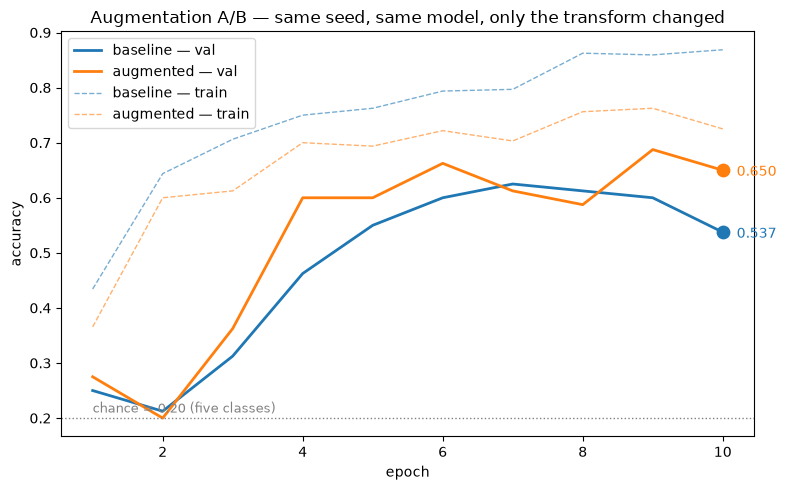

baseline  val 0.537   train 0.869   overfitting gap +0.331
augmented val 0.650   train 0.725   overfitting gap +0.075

GAP = +0.113 of validation accuracy from augmentation alone
=== baseline (no augmentation) ===
epoch  1/10   train 0.434   val 0.250
epoch  2/10   train 0.644   val 0.212
epoch  3/10   train 0.706   val 0.312
epoch  4/10   train 0.750   val 0.463
epoch  5/10   train 0.762   val 0.550
epoch  6/10   train 0.794   val 0.600
epoch  7/10   train 0.797   val 0.625
epoch  8/10   train 0.863   val 0.613
epoch  9/10   train 0.859   val 0.600
epoch 10/10   train 0.869   val 0.537

=== augmented ===
epoch  1/10   train 0.366   val 0.275
epoch  2/10   train 0.600   val 0.200
epoch  3/10   train 0.613   val 0.362
epoch  4/10   train 0.700   val 0.600
epoch  5/10   train 0.694   val 0.600
epoch  6/10   train 0.722   val 0.662
epoch  7/10   train 0.703   val 0.613
epoch  8/10   train 0.756   val 0.588
epoch  9/10   train 0.762   val 0.688
epoch 10/10   train 0.725   val 0.650

baseli

In [70]:
# ────────────────────────────────────────────────────────────────────
# 1) plt.plot(range(1, EPOCHS+1), baseline_val, label="baseline") and same for aug_val.
# 2) Dashed train curves on the same figure help diagnose overfitting at a glance.
# 3) Mark the final points with plt.scatter([EPOCHS], [...]) for emphasis.
# 4) GAP = aug_val[-1] - baseline_val[-1]. Positive means augmentation helped.
#
# ١) `plt.plot(range(1, EPOCHS+1), baseline_val, label="baseline")` ومثله لـ`aug_val`.
# ٢) منحنيا تدريب متقطّعان على الشكل ذاته يُشخّصان الإفراط بنظرة.
# ٣) علّم النقاط الأخيرة بـ`plt.scatter([EPOCHS], [...])` للتوكيد.
# ٤) `GAP = aug_val[-1] - baseline_val[-1]`. الموجب يعني أن التكثير نفع.
# ────────────────────────────────────────────────────────────────────

# TODO: Plot the two val curves (solid) and the two train curves (dashed), compute GAP.
# مهمة: ارسم منحنيَي التحقّق (ممتلئَين) ومنحنيَي التدريب (متقطّعَين)، واحسب `GAP`.
DEVICE = torch.device("cpu")
print(f"using {DEVICE}")
print("=== baseline (no augmentation) ===")
baseline_train, baseline_val = run_training(baseline_transform)

print("\n=== augmented ===")
aug_train, aug_val = run_training(aug_transform)

epochs = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, baseline_val,   color="tab:blue",   linewidth=2, label="baseline — val")
ax.plot(epochs, aug_val,        color="tab:orange", linewidth=2, label="augmented — val")
ax.plot(epochs, baseline_train, color="tab:blue",   linewidth=1, linestyle="--",
        alpha=0.6, label="baseline — train")
ax.plot(epochs, aug_train,      color="tab:orange", linewidth=1, linestyle="--",
        alpha=0.6, label="augmented — train")

ax.scatter([EPOCHS], [baseline_val[-1]], color="tab:blue",   s=80, zorder=5)
ax.scatter([EPOCHS], [aug_val[-1]],      color="tab:orange", s=80, zorder=5)
ax.annotate(f"{baseline_val[-1]:.3f}", (EPOCHS, baseline_val[-1]),
            textcoords="offset points", xytext=(10, -4), color="tab:blue")
ax.annotate(f"{aug_val[-1]:.3f}", (EPOCHS, aug_val[-1]),
            textcoords="offset points", xytext=(10, -4), color="tab:orange")

ax.axhline(0.20, ls=":", lw=1, color="grey")
ax.text(1, 0.21, "chance = 0.20 (five classes)", fontsize=9, color="grey")

ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("Augmentation A/B — same seed, same model, only the transform changed")
ax.legend()
plt.tight_layout()
plt.show()

GAP = aug_val[-1] - baseline_val[-1]
print(f"baseline  val {baseline_val[-1]:.3f}   train {baseline_train[-1]:.3f}   "
      f"overfitting gap {baseline_train[-1] - baseline_val[-1]:+.3f}")
print(f"augmented val {aug_val[-1]:.3f}   train {aug_train[-1]:.3f}   "
      f"overfitting gap {aug_train[-1] - aug_val[-1]:+.3f}")
print(f"\nGAP = {GAP:+.3f} of validation accuracy from augmentation alone")

import time

print("=== baseline (no augmentation) ===")
start = time.perf_counter()
baseline_train, baseline_val = run_training(baseline_transform)
baseline_time = time.perf_counter() - start

print("\n=== augmented ===")
start = time.perf_counter()
aug_train, aug_val = run_training(aug_transform)
aug_time = time.perf_counter() - start

print(f"\nbaseline {baseline_time:.1f}s   augmented {aug_time:.1f}s")

## Save your artefact

`pool_aug_check.json` holds what tomorrow can check against: the predicted vs real
pool shape, the mini CNN's parameter count, the batch-norm check, the validity dictionary,
and the A/B numbers you just measured.

<div dir="rtl" align="right">

## احفظ أثرك

يحفظ `pool_aug_check.json` ما يستطيع الغد التحقّق منه: شكل التجميع المتنبَّأ به مقابل
الحقيقي، وعدد معاملات الشبكة الصغيرة، وفحص تطبيع الدفعات، وقاموس الصلاحية، وأرقام A/B التي قسِتها للتوّ.

</div>

In [71]:
import json

pool_aug_check = {
    "predicted_pool_shape": PREDICTED_POOL_SHAPE,
    "real_pool_shape":      list(pooled_max.shape),
    "mini_cnn_params":      sum(p.numel() for p in make_mini_cnn().parameters()),
    "cnn_params":           sum(p.numel() for p in make_cnn().parameters()),
    "batchnorm_by_hand_gap": BN_GAP,
    "validity":             {k: bool(v[0]) for k, v in VALIDITY.items()},
    "epochs":               EPOCHS,
    "baseline_val_final":   float(baseline_val[-1]),
    "augmented_val_final":  float(aug_val[-1]),
    "val_gap":              float(GAP),
    "baseline_seconds":     round(baseline_time, 1),
    "augmented_seconds":    round(aug_time, 1),
}

path = ARTEFACT_DIR / "pool_aug_check.json"
path.write_text(json.dumps(pool_aug_check, indent=2))
print(f"wrote {path}")
print(json.dumps(pool_aug_check, indent=2))

wrote /Users/leen/AIEP_Olo_student/week_4_cnn_finetuning/labs/D1_pool_aug/artefacts/pool_aug_check.json
{
  "predicted_pool_shape": 79,
  "real_pool_shape": [
    79,
    79
  ],
  "mini_cnn_params": 155429,
  "cnn_params": 155541,
  "batchnorm_by_hand_gap": 9.5367431640625e-07,
  "validity": {
    "horizontal_flip": true,
    "vertical_flip": false,
    "rotation_15deg": true,
    "rotation_180deg": false,
    "grayscale": false
  },
  "epochs": 10,
  "baseline_val_final": 0.5375,
  "augmented_val_final": 0.65,
  "val_gap": 0.11250000000000004,
  "baseline_seconds": 26.0,
  "augmented_seconds": 28.9
}


## Sanity check

<div dir="rtl" align="right">

## فحص السلامة

</div>


In [72]:
check(tuple(pooled_max.shape) == (PREDICTED_POOL_SHAPE, PREDICTED_POOL_SHAPE),
      f"MaxPool output shape must match your predicted size — got "
      f"{tuple(pooled_max.shape)} vs predicted {PREDICTED_POOL_SHAPE}",
      f"يجب أن يُطابق شكل خرج `MaxPool` حجمك المتنبَّأ به، والناتج "
      f"{tuple(pooled_max.shape)} مقابل {PREDICTED_POOL_SHAPE}")

check(tuple(pooled_avg.shape) == tuple(pooled_max.shape),
      "MaxPool and AvgPool with the same kernel/stride must produce the same shape",
      "`MaxPool` و`AvgPool` بنفس النواة والخطوة يجب أن يُنتجا الشكل نفسه")

check(sum(p.numel() for p in make_mini_cnn().parameters()) < 200_000,
      "the mini CNN should stay small (<200k params) — otherwise training is too slow",
      "يجب أن تبقى الشبكة الصغيرة صغيرة (<٢٠٠ ألف معامل) وإلا كان التدريب بطيئًا")

check(all(len(VALIDITY[k][1].split()) >= 6 for k in VALIDITY),
      f"write a real reason (6+ words) for each of the five transforms — got "
      f"{ {k: len(v[1].split()) for k, v in VALIDITY.items()} } words",
      f"اكتب سببًا حقيقيًّا (٦ كلمات فأكثر) لكل تحويل، وعدد الكلمات الحاليّ "
      f"{ {k: len(v[1].split()) for k, v in VALIDITY.items()} }")

check(VALIDITY["horizontal_flip"][0] is True and VALIDITY["vertical_flip"][0] is False,
      "horizontal_flip must be True and vertical_flip must be False for this dataset",
      "يجب أن يكون `horizontal_flip` صحيحًا و`vertical_flip` خاطئًا لهذه البيانات")

check(baseline_val[-1] > 0.30 and aug_val[-1] > 0.30,
      f"both runs should reach at least 30% val accuracy — got baseline {baseline_val[-1]:.2f}, "
      f"augmented {aug_val[-1]:.2f}. If much lower, check the DataLoader and the model.",
      f"يجب أن تبلغ التشغيلتان ٣٠٪ دقّة تحقّق على الأقل — الناتج أساس {baseline_val[-1]:.2f}، "
      f"مكثَّر {aug_val[-1]:.2f}. فإن كان أقل بكثير فافحص الـ`DataLoader` والنموذج.")

check(GAP > -0.05,
      f"augmentation should not dramatically hurt val accuracy — gap {GAP:+.3f}. "
      "If strongly negative, your aug_transform is probably too aggressive or includes "
      "an invalid transform.",
      f"لا ينبغي أن يضرّ التكثير دقّة التحقّق كثيرًا — الفجوة {GAP:+.3f}. فإن كانت "
      "سالبة بشدّة فتحويلك المكثَّر عدوانيّ أو يحوي تحويلًا غير صالح.")

n_bn = sum(isinstance(m, nn.BatchNorm2d) for m in make_cnn().modules())
check(n_bn == 3,
      f"make_cnn needs one nn.BatchNorm2d after each of its three convolutions — found {n_bn}",
      f"تحتاج `make_cnn` إلى `nn.BatchNorm2d` بعد كلٍّ من التفافاتها الثلاثة، والموجود {n_bn}")

check(BN_GAP < 1e-5,
      f"batch norm by hand must match nn.BatchNorm2d to 1e-5 — largest gap {BN_GAP:.1e} "
      f"(the usual cause is the N - 1 variance; batch norm divides by N)",
      f"يجب أن يطابق تطبيع الدفعات بيدك `nn.BatchNorm2d` حتى ١e-٥، وأكبر فرق {BN_GAP:.1e} "
      f"(والسبب المعتاد تباين بالقسمة على N − 1، وتطبيع الدفعات يقسم على N)")

import inspect
try:
    loop_source = inspect.getsource(run_training)
except (OSError, TypeError):          # source not recoverable here: do not fail the student for it
    loop_source = "model.train() model.eval()"
check("model.train()" in loop_source and "model.eval()" in loop_source,
      "run_training must call model.train() before each training pass and model.eval() before "
      "each validation pass",
      "يجب أن تنادي `run_training` الدالة `model.train()` قبل كل تمريرة تدريب و`model.eval()` "
      "قبل كل تمريرة تحقّق")

report()

──────────────────────────────────────────────────────────────────
  ✓  MaxPool output shape must match your predicted size — got (79, 79) vs predicted 79
  ✓  MaxPool and AvgPool with the same kernel/stride must produce the same shape
  ✓  the mini CNN should stay small (<200k params) — otherwise training is too slow
  ✓  write a real reason (6+ words) for each of the five transforms — got {'horizontal_flip': 28, 'vertical_flip': 27, 'rotation_15deg': 23, 'rotation_180deg': 26, 'grayscale': 26} words
  ✓  horizontal_flip must be True and vertical_flip must be False for this dataset
  ✓  both runs should reach at least 30% val accuracy — got baseline 0.54, augmented 0.65. If much lower, check the DataLoader and the model.
  ✓  augmentation should not dramatically hurt val accuracy — gap +0.113. If strongly negative, your aug_transform is probably too aggressive or includes an invalid transform.
  ✓  make_cnn needs one nn.BatchNorm2d after each of its three convolutions — found 3
  ✓  b

## Section 5 — Stretch: strength sweep  *(≈15 min, home-friendly)*

One open task. The augmentation you used was *mild*. What if you crank it up?

Build three more augmentation pipelines: `light`, `aggressive`, `extreme` — and train
once per setting. Plot final val accuracy against strength. The curve usually rises,
plateaus, and then falls — because at some point you're teaching the model to classify
images that no one would ever photograph.

Try these settings (pick values; the point is to see the curve):

| strength    | rotation | crop scale   | jitter |
|-------------|----------|--------------|--------|
| none        | 0        | 1.0          | 0.0    |
| light       | 10°      | (0.9, 1.0)   | 0.1    |
| medium      | 15°      | (0.8, 1.0)   | 0.2    |
| aggressive  | 30°      | (0.6, 1.0)   | 0.4    |
| extreme     | 60°      | (0.3, 1.0)   | 0.8    |

Write one sentence afterwards on where the peak sat and why.

<div dir="rtl" align="right">

## القسم الخامس — إضافيّ: مَسح شدّة التكثير *(نحو ١٥ دقيقة، مناسب للبيت)*

مهمّة مفتوحة واحدة. التكثير الذي استعملتَه *خفيف*. فماذا لو رفعتَه؟

ابنِ ثلاثة خطوط تكثير إضافية: `light` و`aggressive` و`extreme` — ودرّب مرّة لكل
إعداد. ارسم دقّة التحقّق النهائية مقابل الشدّة. يرتفع المنحنى عادةً، فيستوي، فينحدر —
لأنك عند نقطة ما تُعلّم النموذج تصنيف صور لن يصوِّرها أحد.

جرِّب هذه الإعدادات (اختر القيم، فالمقصود رؤية المنحنى):

| الشدّة       | التدوير | `crop scale` | الخضخضة |
|-------------|---------|--------------|---------|
| `none`      | ٠        | ١٫٠          | ٠٫٠     |
| `light`     | ١٠°      | (0.9, 1.0)   | ٠٫١     |
| `medium`    | ١٥°      | (0.8, 1.0)   | ٠٫٢     |
| `aggressive`| ٣٠°      | (0.6, 1.0)   | ٠٫٤     |
| `extreme`   | ٦٠°      | (0.3, 1.0)   | ٠٫٨     |

واكتب جملة بعدها عن موقع الذروة وسببها.

</div>


In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over the five settings; build a transform per setting.
# 2) Call run_training() for each (will take ~5x the baseline time).
# 3) Plot settings on x-axis, final val accuracy on y-axis.
# 4) None is the baseline you already ran — reuse the number.
#
# ١) كرِّر على الإعدادات الخمسة؛ ابنِ تحويلًا لكل إعداد.
# ٢) نادِ `run_training()` لكلٍّ منها (ستأخذ نحو ٥× زمن الأساس).
# ٣) ارسم الإعدادات على المحور الأفقيّ ودقّة التحقّق النهائية على الرأسيّ.
# ٤) `none` هي الأساس الذي شغّلته أصلًا — فأعد استعمال رقمه.
# ────────────────────────────────────────────────────────────────────

# TODO: Build five transforms with the strengths above and train once per setting.
# مهمة: ابنِ خمسة تحويلات بالشدّات أعلاه ودرّب مرّة لكل إعداد.

## What's next — the rest of the week

Today you built the two most-used tricks in CNN training. The next four days scale up
to real models and real tasks.

| Day | Theme | What you build |
|---|---|---|
| **D1** (today) | **Pooling + Augmentation** | train a mini CNN with and without aug |
| **D2** | **SOTA architectures** | VGG, ResNet, DenseNet — read the lineage, compare parameter counts |
| **D3** | **Image segmentation** | per-pixel classification; U-Net |
| **D4** | **Object detection** | boxes and classes; YOLO on real photos |
| **D5** | **Generative models in CV** | VAEs, GANs, diffusion — the networks that make images |

Your mini CNN from today becomes **unnecessary** on D2 and D5 — you'll use pretrained
backbones instead. But every one of those backbones is pooling + augmentation at
scale, so what you built today is what makes them work.

**Keep this notebook open** — the `pool_aug_check.json` you just saved is referenced
on D2 when we compare your from-scratch val accuracy to a pretrained ResNet's.

<div dir="rtl" align="right">

## ما التالي — بقيّة الأسبوع

اليوم بنيتَ أكثر حيلتين استعمالًا في تدريب الشبكات الالتفافية. والأيام الأربعة
التالية ترفع المقياس إلى نماذج حقيقية ومهامّ حقيقية.

| اليوم | الموضوع | ما ستبنيه |
|---|---|---|
| **اليوم ١** (اليوم) | **التجميع والتكثير** | تدريب شبكة صغيرة بتكثير وبدونه |
| **اليوم ٢** | **المعماريات الرائدة** | VGG وResNet وDenseNet — اقرأ السلالة وقارن أعداد المعاملات |
| **اليوم ٣** | **تجزئة الصور** | تصنيف لكل بكسل؛ U-Net |
| **اليوم ٤** | **كشف الكائنات** | صناديق وفئات؛ YOLO على صور حقيقية |
| **اليوم ٥** | **النماذج التوليدية في الرؤية** | VAEs وGANs والنشر — الشبكات التي تصنع الصور |

شبكتك الصغيرة من اليوم ستصير **غير ضرورية** في اليوم الثاني واليوم الخامس — إذ
ستستعمل أعمدة فقرية مُدرَّبة مسبقًا. لكن كلّ عمود منها هو تجميع وتكثير على نطاق واسع،
فما بنيتَه اليوم هو ما يُشغِّلها.

**أبقِ هذا الدفتر مفتوحًا** — فـ`pool_aug_check.json` الذي حفظته للتوّ مرجعٌ في اليوم
الثاني حين نقارن دقّة التحقّق من الصفر عندك بدقّة ResNet مُدرَّبة مسبقًا.

</div>
